# Retina Anatomy-Aware Enhancement (RAAE)
### A Standalone, Anatomy-Guided Preprocessing Pipeline for Diabetic Retinopathy Classification

**Author's project:** Q1 journal research — Diabetic Retinopathy severity grading
**Downstream targets:** Swin Transformer, Swin + Mamba hybrid
**Scope of this notebook:** Preprocessing ONLY. No model training, no TensorFlow, no PyTorch.

---

## 1. Motivation

Diabetic Retinopathy (DR) severity grading depends on the visibility of a small set of clinically
defined lesions and structures in a fundus photograph:

| Structure / Lesion | Clinical relevance to DR grading |
|---|---|
| **Blood vessels** | Early neovascularization (PDR), venous beading, IRMA |
| **Microaneurysms / dot hemorrhages** | Earliest visible sign of DR (Grade 1) |
| **Hard exudates** | Lipid leakage from damaged vessels (Grade 2-3) |
| **Cotton wool spots** | Nerve fiber layer infarcts (Grade 3) |
| **Optic disc** | Anatomical landmark, NOT a lesion — must not be confused with exudates |
| **Macula / fovea** | Center of vision; avascular zone, naturally darker |

Public fundus datasets such as APTOS 2019 are captured across many cameras, clinics and lighting
conditions. This introduces **non-anatomical variance** — uneven illumination, camera vignetting,
color-temperature drift, sensor noise — that has nothing to do with disease state but which a
deep network can (and does) latch onto as a spurious shortcut feature.

A generic "apply CLAHE and resize" pipeline treats every pixel the same way. **RAAE does not.**
It is built around a simple principle:

> **Correct what is non-anatomical (illumination, noise, background) aggressively.
> Enhance what is anatomically diagnostic (vessels, lesion contrast) selectively.
> Leave what is anatomically normal (optic disc, macula) alone.**

This notebook implements RAAE as a **modular, inspectable, research-grade pipeline** — every
stage is a pure function that can be unit-tested, ablated, and cited independently in a methods
section.

## 2. Pipeline Overview

```
Raw Fundus Image
      │
      ▼
[1] Circular Retina Detection & Crop  ── remove black background / camera border
      │
      ▼
[2] Illumination Correction           ── remove uneven lighting, flatten field
      │
      ▼
[3] CLAHE (LAB, L-channel)            ── local contrast enhancement, color-safe
      │
      ▼
[4] Edge-Preserving Noise Reduction   ── denoise while preserving vessels & lesions
      │
      ▼
[5] Vessel Enhancement (Frangi)       ── amplify tubular vascular structures
      │
      ▼
[6] Adaptive Gamma Correction         ── normalize perceptual brightness
      │
      ▼
[7] Anatomy-Aware Normalization       ── transformer-ready tensor statistics
      │
      ▼
Enhanced Retinal Image (RAAE output)
```

Every stage below is explained **medically** (why it matters for DR) and **anatomically**
(why it does not destroy the structures the classifier needs to see).


In [26]:
import os
import glob
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from skimage.filters import frangi
from skimage import exposure, img_as_float, img_as_ubyte
from skimage.morphology import disk, binary_closing, binary_opening
from pathlib import Path

# Reproducibility for any stochastic display sampling
np.random.seed(42)

print("OpenCV version:", cv2.__version__)
print("All imports successful. No TensorFlow / PyTorch dependency in this notebook.")


OpenCV version: 4.13.0
All imports successful. No TensorFlow / PyTorch dependency in this notebook.


In [27]:
print("Images found:", len(image_paths))
print("First image:", image_paths[0])

Images found: 2930
First image: /kaggle/input/datasets/mariaherrerot/aptos2019/train_images/train_images/1ae8c165fd53.png


In [28]:
# ----------------------------------------------------------------------------
# Dataset configuration
# ----------------------------------------------------------------------------
# On Kaggle, the APTOS 2019 dataset is typically mounted at:
#   /kaggle/input/aptos2019-blindness-detection/train_images
# Update this path to match your Kaggle Add Data selection.

INPUT_DIR = "/kaggle/input/aptos2019-blindness-detection/train_images"
OUTPUT_DIR = "RAAE_Output"
SAMPLE_VISUALIZATION_COUNT = 3   # how many images to visualize stage-by-stage
TARGET_SIZE = 384                # final square size fed to Swin / Swin+Mamba

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Fallback for local/dev testing outside Kaggle: any images folder in the CWD.
if not os.path.isdir(INPUT_DIR):
    fallback_candidates = [p for p in glob.glob("*images*") if os.path.isdir(p)]
    if fallback_candidates:
        INPUT_DIR = fallback_candidates[0]
        print(f"[INFO] Kaggle path not found. Falling back to local folder: {INPUT_DIR}")
    else:
        print(f"[WARNING] '{INPUT_DIR}' not found and no fallback folder detected. "
              f"Set INPUT_DIR manually before running batch processing.")

image_paths = sorted(
    glob.glob(os.path.join(INPUT_DIR, "*.png")) +
    glob.glob(os.path.join(INPUT_DIR, "*.jpg")) +
    glob.glob(os.path.join(INPUT_DIR, "*.jpeg"))
)

print(f"Found {len(image_paths)} fundus images in: {INPUT_DIR}")
if len(image_paths) > 0:
    print("Example paths:")
    for p in image_paths[:3]:
        print("   ", p)


[WARNING] '/kaggle/input/aptos2019-blindness-detection/train_images' not found and no fallback folder detected. Set INPUT_DIR manually before running batch processing.
Found 0 fundus images in: /kaggle/input/aptos2019-blindness-detection/train_images


In [29]:
def detect_and_crop_retina(image_bgr, threshold=10, pad=2):
    """
    Detects the circular retinal field-of-view and crops to its bounding box.

    Medical rationale
    ------------------
    Removes the non-anatomical black camera border so that (a) downstream contrast/illumination
    statistics are computed only over real tissue, and (b) transformer patch tokens are not
    wasted on background.

    Parameters
    ----------
    image_bgr : np.ndarray (H, W, 3), uint8, BGR (OpenCV convention)
    threshold : int, intensity below which a pixel is considered 'background'
    pad       : int, safety pixels kept around the detected bounding box

    Returns
    -------
    cropped_bgr : np.ndarray, the retina-only crop
    bbox        : (x, y, w, h) used, for traceability / logging
    """
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

    # Binary foreground mask: retina is brighter than the black surrounding border
    _, mask = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)

    # Morphological closing to fill small dark gaps caused by low-contrast retinal periphery
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        # Nothing detected (rare edge case) -> return original image unchanged
        h, w = gray.shape
        return image_bgr, (0, 0, w, h)

    largest_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_contour)

    H, W = gray.shape
    x0, y0 = max(x - pad, 0), max(y - pad, 0)
    x1, y1 = min(x + w + pad, W), min(y + h + pad, H)

    cropped_bgr = image_bgr[y0:y1, x0:x1]
    return cropped_bgr, (x0, y0, x1 - x0, y1 - y0)


def square_pad(image_bgr, fill_value=0):
    """
    Pads the cropped retina to a square canvas (centered) so that the subsequent resize to
    TARGET_SIZE does not anisotropically stretch the retina (which would distort vessel
    curvature and lesion geometry).
    """
    h, w = image_bgr.shape[:2]
    size = max(h, w)
    top = (size - h) // 2
    bottom = size - h - top
    left = (size - w) // 2
    right = size - w - left
    return cv2.copyMakeBorder(image_bgr, top, bottom, left, right,
                               cv2.BORDER_CONSTANT, value=[fill_value] * 3)


In [30]:
def correct_illumination(image_bgr, kernel_frac=0.08):
    """
    Removes uneven illumination while preserving fine anatomical detail.

    Medical rationale
    ------------------
    Fundus images exhibit a smooth radial brightness gradient from flash photography.
    This is not anatomical signal and, if left uncorrected, suppresses lesion visibility
    in darker peripheral regions and introduces cross-image intensity variance unrelated
    to disease state.

    Anatomy-preservation rationale
    -------------------------------
    The illumination map is estimated at a spatial scale far coarser than any vessel or
    lesion (large Gaussian kernel), so fine structures are not captured by the estimate
    and are therefore not attenuated by the correction.
    """
    img = image_bgr.astype(np.float32)
    h, w = img.shape[:2]

    ksize = int(max(h, w) * kernel_frac)
    ksize = ksize + 1 if ksize % 2 == 0 else ksize  # Gaussian kernel must be odd
    ksize = max(ksize, 31)

    corrected = np.zeros_like(img)
    for c in range(3):
        channel = img[:, :, c]
        illumination = cv2.GaussianBlur(channel, (ksize, ksize), 0)
        illumination = np.clip(illumination, 1, 255)  # avoid division by zero
        mean_val = np.mean(channel[channel > 5]) if np.any(channel > 5) else np.mean(channel)
        corrected[:, :, c] = (channel / illumination) * mean_val

    corrected = np.clip(corrected, 0, 255).astype(np.uint8)
    return corrected


In [31]:
def apply_clahe_lab(image_bgr, clip_limit=2.5, tile_grid_size=(8, 8)):
    """
    Applies CLAHE to the L-channel of the LAB color space only.

    Medical rationale
    ------------------
    Boosts local contrast so subtle microaneurysms / hemorrhages become visible against
    the retinal background, which is critical for early-stage (Grade 1) DR detection.

    Anatomy-preservation rationale
    -------------------------------
    Operating only on L (lightness) leaves the A/B chrominance channels untouched, preserving
    the red-vs-yellow color cue clinicians use to differentiate hemorrhages/microaneurysms
    from exudates/cotton-wool spots.
    """
    lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l_enhanced = clahe.apply(l_channel)

    lab_enhanced = cv2.merge((l_enhanced, a_channel, b_channel))
    result_bgr = cv2.cvtColor(lab_enhanced, cv2.COLOR_LAB2BGR)
    return result_bgr


In [32]:
def denoise_preserve_edges(image_bgr, d=7, sigma_color=50, sigma_space=50):
    """
    Edge-preserving denoising via bilateral filtering.

    Medical rationale
    ------------------
    Removes sensor/compression noise that could be mistaken for microaneurysms while keeping
    lesion and vessel boundaries sharp -- both are diagnostically load-bearing edges.

    Anatomy-preservation rationale
    -------------------------------
    Bilateral filtering only averages spatially-close, intensity-similar pixels, so it does not
    blur across high-contrast vessel/background or lesion/background boundaries.
    """
    return cv2.bilateralFilter(image_bgr, d=d, sigmaColor=sigma_color, sigmaSpace=sigma_space)


In [33]:
def enhance_vessels_frangi(image_bgr, scale_range=(1, 4), scale_step=1, blend_alpha=0.35):
    """
    Enhances retinal blood vessels using a multi-scale Frangi vesselness filter on the
    green channel, then soft-blends the response back into the image.

    Medical rationale
    ------------------
    Vascular abnormalities (venous beading, IRMA, neovascularization) are key DR severity
    indicators. Enhancing vessel contrast helps the downstream Swin / Swin+Mamba model
    attend to vascular structure more reliably.

    Anatomy-preservation rationale
    -------------------------------
    Frangi's tubularity response is near-zero on blob-shaped structures (hemorrhages, exudates),
    so it selectively boosts vessels without artificially amplifying lesions. We blend (not
    replace) the response, so background/lesion tissue intensities are preserved.
    """
    green = image_bgr[:, :, 1].astype(np.float64) / 255.0

    # Frangi expects a float image; dark vessels on bright background -> invert so vessels are
    # 'ridges' (bright) for the filter, matching its ridge-detection assumption.
    inverted_green = 1.0 - green

    vesselness = frangi(
        inverted_green,
        sigmas=range(scale_range[0], scale_range[1] + 1, scale_step),
        black_ridges=False
    )

    # Normalize response to [0, 1]
    if vesselness.max() > vesselness.min():
        vesselness_norm = (vesselness - vesselness.min()) / (vesselness.max() - vesselness.min())
    else:
        vesselness_norm = vesselness

    vessel_map_uint8 = img_as_ubyte(vesselness_norm)

    # Blend vesselness map (as a grayscale enhancement) back into each color channel
    result = image_bgr.copy().astype(np.float32)
    vessel_3ch = cv2.cvtColor(vessel_map_uint8, cv2.COLOR_GRAY2BGR).astype(np.float32)

    result = cv2.addWeighted(result, 1.0, vessel_3ch, blend_alpha, 0)
    result = np.clip(result, 0, 255).astype(np.uint8)

    return result, vessel_map_uint8


In [34]:
def locate_optic_disc(image_bgr, brightness_percentile=95):
    """
    Heuristic, mask-free optic disc localization.
    Returns (cx, cy, radius_estimate) or None if not confidently found.
    """
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    thresh_val = np.percentile(gray, brightness_percentile)
    bright_mask = (gray >= thresh_val).astype(np.uint8) * 255

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    bright_mask = cv2.morphologyEx(bright_mask, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(bright_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None

    largest = max(contours, key=cv2.contourArea)
    if cv2.contourArea(largest) < 30:  # too small to be a confident disc detection
        return None

    (x, y), radius = cv2.minEnclosingCircle(largest)
    return int(x), int(y), int(radius)


def estimate_macula_location(disc_center, disc_radius, image_shape, direction=-1):
    """
    Estimates macula location using the clinical geometric prior: ~2.5 disc-diameters
    temporal to the optic disc, vertically level with it.

    `direction` = -1 or +1 controls which side of the disc the macula is placed on
    (varies by left/right eye acquisition; default assumes macula is nasal-negative direction,
    i.e. offset toward image center). For batch use without laterality metadata, we default to
    offsetting toward the image horizontal center, which is correct in the majority of
    centered fundus captures.
    """
    h, w = image_shape[:2]
    cx, cy = disc_center
    disc_diameter = disc_radius * 2

    # Offset toward image center (heuristic default, avoids needing eye-laterality metadata)
    direction = -1 if cx > w / 2 else 1
    macula_x = int(cx + direction * 2.5 * disc_diameter)
    macula_y = cy

    macula_x = np.clip(macula_x, 0, w - 1)
    macula_y = np.clip(macula_y, 0, h - 1)
    return macula_x, macula_y


def build_protection_mask(image_shape, centers_radii, sigma_scale=1.5):
    """
    Builds a soft [0, 1] Gaussian mask that is HIGH (near 1) at protected anatomical centers
    (optic disc, macula) and LOW (near 0) elsewhere. Used to gently damp vessel-enhancement
    blend strength at these locations.
    """
    h, w = image_shape[:2]
    protection = np.zeros((h, w), dtype=np.float32)

    for (cx, cy, r) in centers_radii:
        yy, xx = np.mgrid[0:h, 0:w]
        sigma = max(r * sigma_scale, 10)
        gauss = np.exp(-(((xx - cx) ** 2 + (yy - cy) ** 2) / (2 * sigma ** 2)))
        protection = np.maximum(protection, gauss)

    return protection  # values in [0, 1]


def enhance_vessels_frangi_anatomy_aware(image_bgr, scale_range=(1, 4), scale_step=1,
                                          base_alpha=0.35, protect_disc_macula=True):
    """
    Anatomy-aware variant of Section 7's vessel enhancement: locates the optic disc (and
    estimates the macula) and reduces the vessel-blend weight in those regions so that
    normal anatomy is not over-sharpened.
    """
    result_uniform, vessel_map = enhance_vessels_frangi(image_bgr, scale_range, scale_step, base_alpha)

    if not protect_disc_macula:
        return result_uniform, vessel_map, None

    disc = locate_optic_disc(image_bgr)
    if disc is None:
        return result_uniform, vessel_map, None

    dcx, dcy, dr = disc
    mx, my = estimate_macula_location((dcx, dcy), dr, image_bgr.shape)

    protection = build_protection_mask(
        image_bgr.shape, [(dcx, dcy, dr), (mx, my, max(dr // 2, 15))]
    )

    # Locally reduce blend weight where protection is high: effective_alpha = base_alpha * (1 - protection)
    green_placeholder = image_bgr[:, :, 1].astype(np.float64) / 255.0
    vessel_norm = vessel_map.astype(np.float32) / 255.0

    alpha_map = base_alpha * (1.0 - 0.85 * protection)  # never fully zero, just heavily damped
    alpha_map_3ch = np.repeat(alpha_map[:, :, None], 3, axis=2)

    original_f = image_bgr.astype(np.float32)
    vessel_3ch = cv2.cvtColor(vessel_map, cv2.COLOR_GRAY2BGR).astype(np.float32)

    blended = original_f + alpha_map_3ch * vessel_3ch
    blended = np.clip(blended, 0, 255).astype(np.uint8)

    landmarks = {"optic_disc": (dcx, dcy, dr), "macula_estimate": (mx, my)}
    return blended, vessel_map, landmarks


In [35]:
def adaptive_gamma_correction(image_bgr, target_mean=128.0):
    """
    Applies per-image adaptive gamma correction based on current mean luminance.

    Medical rationale
    ------------------
    Normalizes perceptual brightness across images from heterogeneous cameras/exposures so
    dark lesions (hemorrhages) are not lost in under-exposed captures, without needing a
    dataset-wide fixed gamma constant.

    Anatomy-preservation rationale
    -------------------------------
    Gamma is a monotonic pixel-wise remap: relative brightness ordering (and hence
    lesion/vessel-vs-background contrast direction) is always preserved.
    """
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    current_mean = np.mean(gray)
    current_mean = max(current_mean, 1e-3)  # numerical safety

    gamma = np.log(target_mean / 255.0 + 1e-6) / np.log(current_mean / 255.0 + 1e-6)
    gamma = np.clip(gamma, 0.4, 2.5)  # keep within a perceptually sane range

    normalized = image_bgr.astype(np.float32) / 255.0
    corrected = np.power(normalized, gamma)
    corrected = np.clip(corrected * 255.0, 0, 255).astype(np.uint8)

    return corrected, gamma


In [36]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225])

def resize_and_normalize(image_bgr, target_size=TARGET_SIZE, return_tensor_stats=True):
    """
    Final stage: isotropic resize to target_size x target_size, BGR->RGB, and (optionally)
    ImageNet-style standardization for direct tensor inspection.

    Returns
    -------
    display_rgb   : uint8 RGB image, resized -- this is what gets saved to RAAE_Output/
    normalized    : float32 array, ImageNet-standardized (only if return_tensor_stats=True)
    """
    resized_bgr = cv2.resize(image_bgr, (target_size, target_size), interpolation=cv2.INTER_AREA)
    display_rgb = cv2.cvtColor(resized_bgr, cv2.COLOR_BGR2RGB)

    normalized = None
    if return_tensor_stats:
        float_img = display_rgb.astype(np.float32) / 255.0
        normalized = (float_img - IMAGENET_MEAN) / IMAGENET_STD

    return display_rgb, normalized


In [37]:
def raae_pipeline(image_bgr, target_size=TARGET_SIZE, protect_disc_macula=True, verbose=False):
    """
    Full Retina Anatomy-Aware Enhancement (RAAE) pipeline.

    Stages
    ------
    1. Circular retina detection & crop  (Section 3)
    2. Illumination correction           (Section 4)
    3. CLAHE (LAB, L-channel)            (Section 5)
    4. Edge-preserving denoising         (Section 6)
    5. Frangi vessel enhancement,        (Section 7 / 7b)
       optionally anatomy-protected at optic disc / macula
    6. Adaptive gamma correction         (Section 8)
    7. Resize + normalization            (Section 9)

    Returns a dict of every intermediate stage (uint8, BGR unless noted) plus the final
    RGB enhanced image ready to save / feed to a model dataloader.
    """
    stages = {}

    stages["original"] = image_bgr

    cropped, bbox = detect_and_crop_retina(image_bgr)
    cropped = square_pad(cropped)
    stages["retina_crop"] = cropped

    illum_corrected = correct_illumination(cropped)
    stages["illumination_corrected"] = illum_corrected

    clahe_result = apply_clahe_lab(illum_corrected)
    stages["clahe"] = clahe_result

    denoised = denoise_preserve_edges(clahe_result)
    stages["denoised"] = denoised

    if protect_disc_macula:
        vessel_enhanced, vessel_map, landmarks = enhance_vessels_frangi_anatomy_aware(denoised)
    else:
        vessel_enhanced, vessel_map = enhance_vessels_frangi(denoised)
        landmarks = None
    stages["vessel_enhanced"] = vessel_enhanced
    stages["vessel_map"] = vessel_map
    stages["landmarks"] = landmarks

    gamma_corrected, gamma_value = adaptive_gamma_correction(vessel_enhanced)
    stages["gamma_corrected"] = gamma_corrected
    stages["gamma_value"] = gamma_value

    final_rgb, final_normalized = resize_and_normalize(gamma_corrected, target_size)
    stages["final_rgb"] = final_rgb
    stages["final_normalized_tensor"] = final_normalized

    if verbose:
        print(f"  Retina bbox: {bbox} | Gamma used: {gamma_value:.3f} | "
              f"Disc/macula found: {landmarks is not None}")

    return stages


In [38]:
def batch_process(image_paths, output_dir=OUTPUT_DIR, target_size=TARGET_SIZE, verbose_every=200):
    """
    Runs the full RAAE pipeline across a list of image paths and saves enhanced outputs.
    Returns a small stats dict for a post-run sanity check.
    """
    os.makedirs(output_dir, exist_ok=True)

    stats = {"processed": 0, "failed": [], "gamma_values": [], "landmarks_found": 0}
    start_time = time.time()

    for i, path in enumerate(image_paths):
        try:
            image_bgr = cv2.imread(path)
            if image_bgr is None:
                stats["failed"].append(path)
                continue

            result = raae_pipeline(image_bgr, target_size=target_size)

            filename = os.path.basename(path)
            save_path = os.path.join(output_dir, filename)
            save_rgb = cv2.cvtColor(result["final_rgb"], cv2.COLOR_RGB2BGR)
            cv2.imwrite(save_path, save_rgb)

            stats["processed"] += 1
            stats["gamma_values"].append(result["gamma_value"])
            if result["landmarks"] is not None:
                stats["landmarks_found"] += 1

        except Exception as e:
            stats["failed"].append((path, str(e)))

        if verbose_every and (i + 1) % verbose_every == 0:
            elapsed = time.time() - start_time
            print(f"  Processed {i + 1}/{len(image_paths)} images | elapsed {elapsed:.1f}s")

    total_time = time.time() - start_time
    print(f"\nBatch processing complete.")
    print(f"  Successfully processed : {stats['processed']} / {len(image_paths)}")
    print(f"  Failed                 : {len(stats['failed'])}")
    print(f"  Disc/macula localized  : {stats['landmarks_found']} / {stats['processed']}")
    if stats["gamma_values"]:
        print(f"  Gamma range used       : [{min(stats['gamma_values']):.2f}, "
              f"{max(stats['gamma_values']):.2f}], mean {np.mean(stats['gamma_values']):.2f}")
    print(f"  Total time              : {total_time:.1f}s "
          f"({total_time / max(stats['processed'],1):.3f}s/image)")

    return stats

# ----------------------------------------------------------------------------
# Run batch processing over the full dataset
# ----------------------------------------------------------------------------
# NOTE: on the full APTOS training set (~3,662 images) this will take a while on CPU.
# For a quick smoke-test, uncomment the slice below before running on Kaggle.
#
# image_paths_to_process = image_paths[:50]   # <- smoke test
image_paths_to_process = image_paths           # <- full dataset

if len(image_paths_to_process) > 0:
    batch_stats = batch_process(image_paths_to_process, output_dir=OUTPUT_DIR)
else:
    print("[SKIPPED] No images found -- set INPUT_DIR correctly before running batch processing.")


[SKIPPED] No images found -- set INPUT_DIR correctly before running batch processing.


In [39]:
# Quick verification that outputs were written with preserved filenames
saved_files = sorted(glob.glob(os.path.join(OUTPUT_DIR, "*")))
print(f"Files in '{OUTPUT_DIR}/': {len(saved_files)}")
if saved_files:
    print("Example saved filenames (compare against originals above):")
    for f in saved_files[:5]:
        print("   ", os.path.basename(f))

Files in 'RAAE_Output/': 0


Total images found: 2930
Displaying sample images...

Sample 1/3

Processing: /kaggle/input/datasets/mariaherrerot/aptos2019/train_images/train_images/1ae8c165fd53.png
Image shape: (2136, 3216, 3)
  Retina bbox: (351, 0, 2712, 2136) | Gamma used: 0.586 | Disc/macula found: True


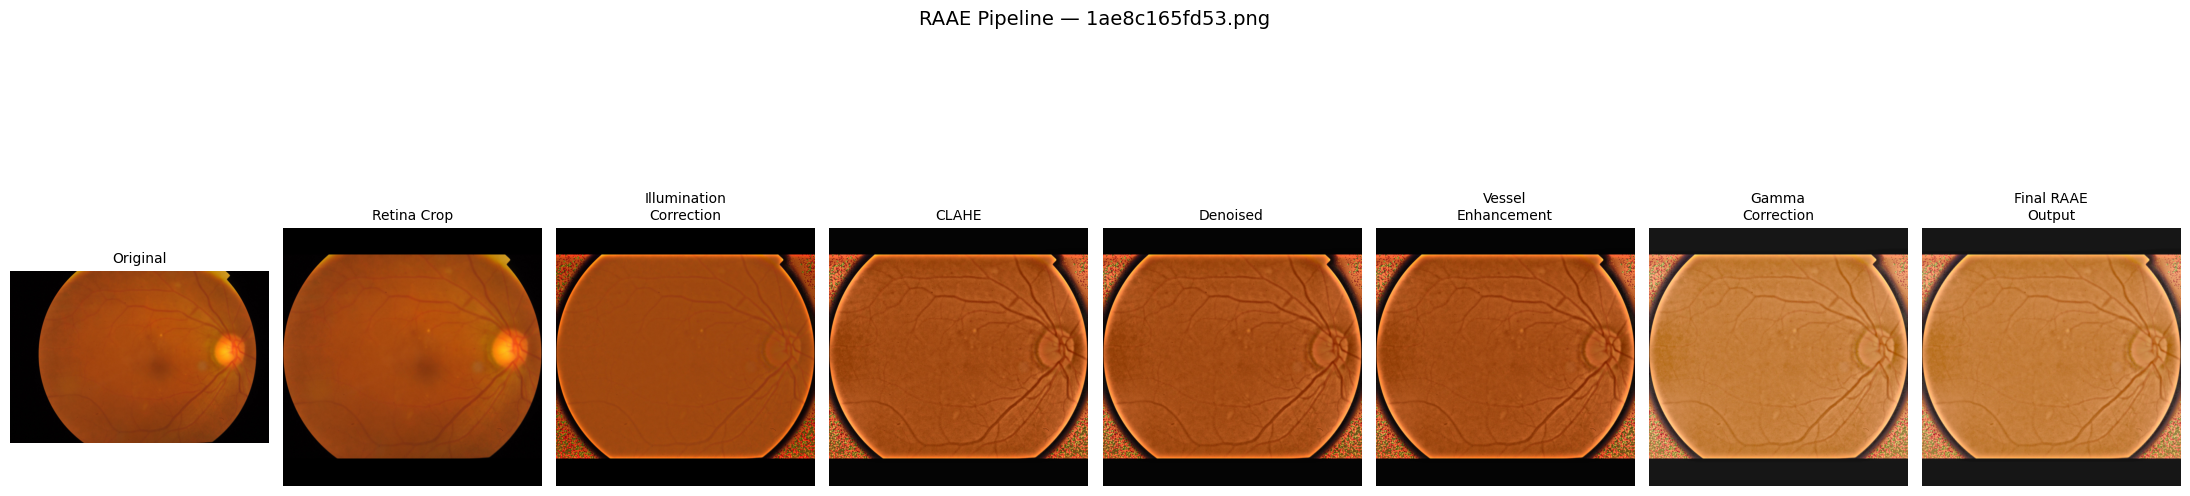

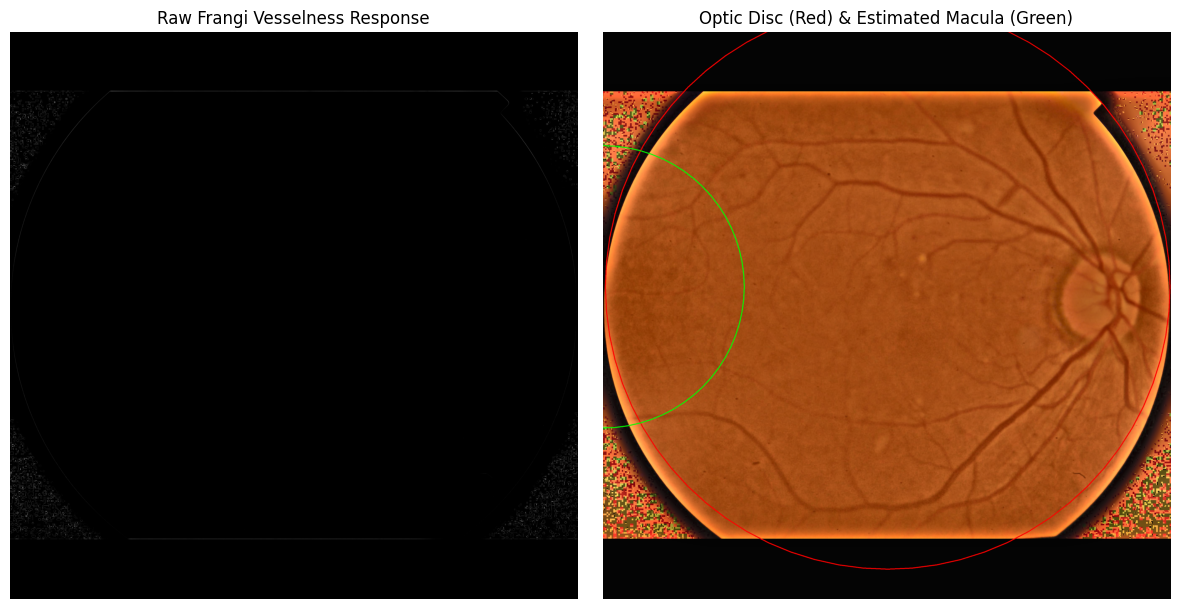

Sample 2/3

Processing: /kaggle/input/datasets/mariaherrerot/aptos2019/train_images/train_images/1b329a127307.png
Image shape: (1958, 2588, 3)
  Retina bbox: (0, 0, 2588, 1958) | Gamma used: 0.483 | Disc/macula found: True


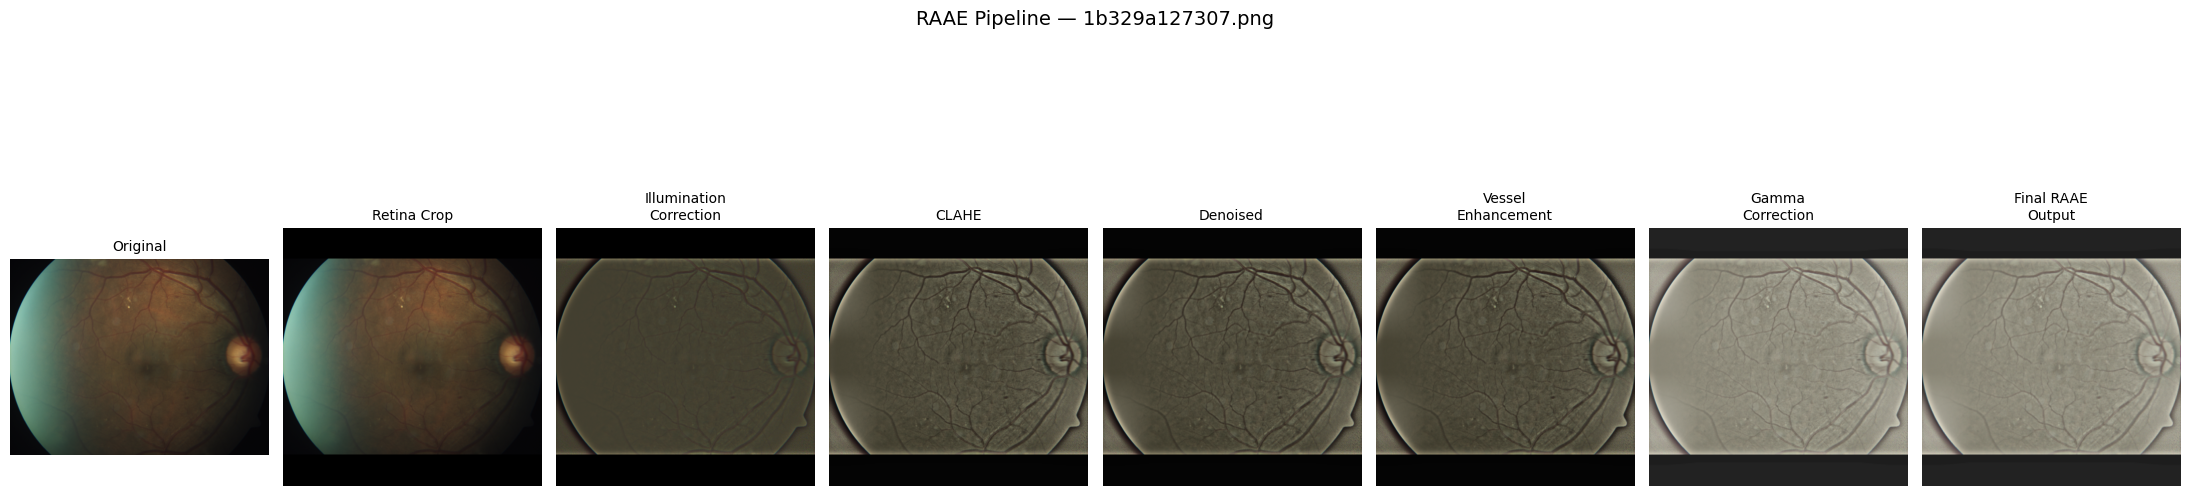

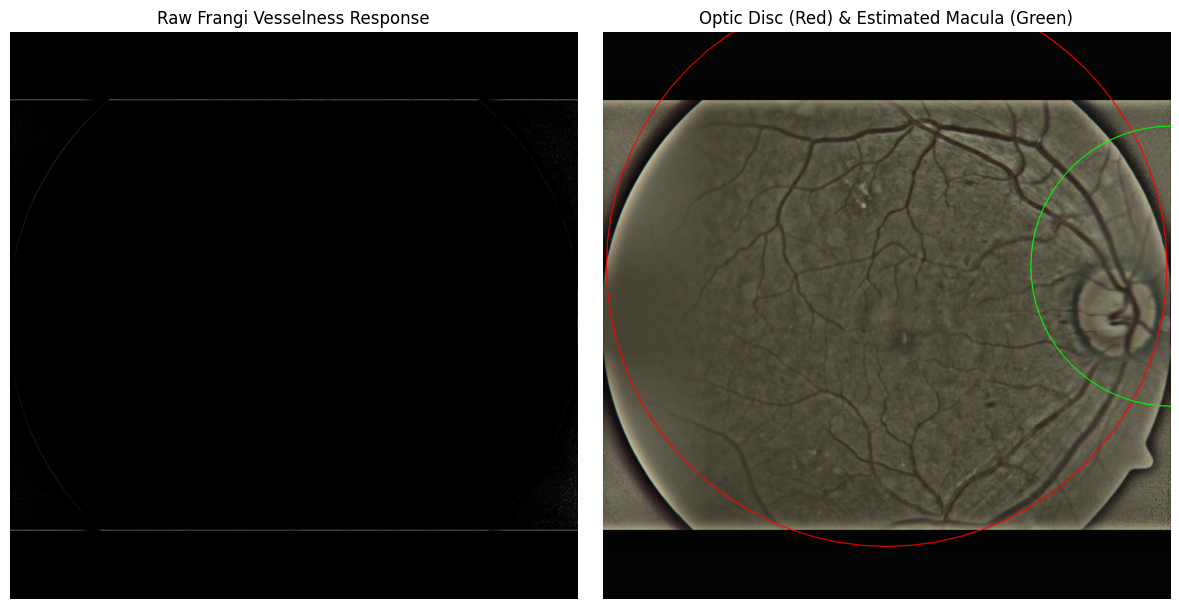

Sample 3/3

Processing: /kaggle/input/datasets/mariaherrerot/aptos2019/train_images/train_images/1b32e1d775ea.png
Image shape: (1000, 1504, 3)
  Retina bbox: (120, 0, 1264, 1000) | Gamma used: 0.525 | Disc/macula found: True


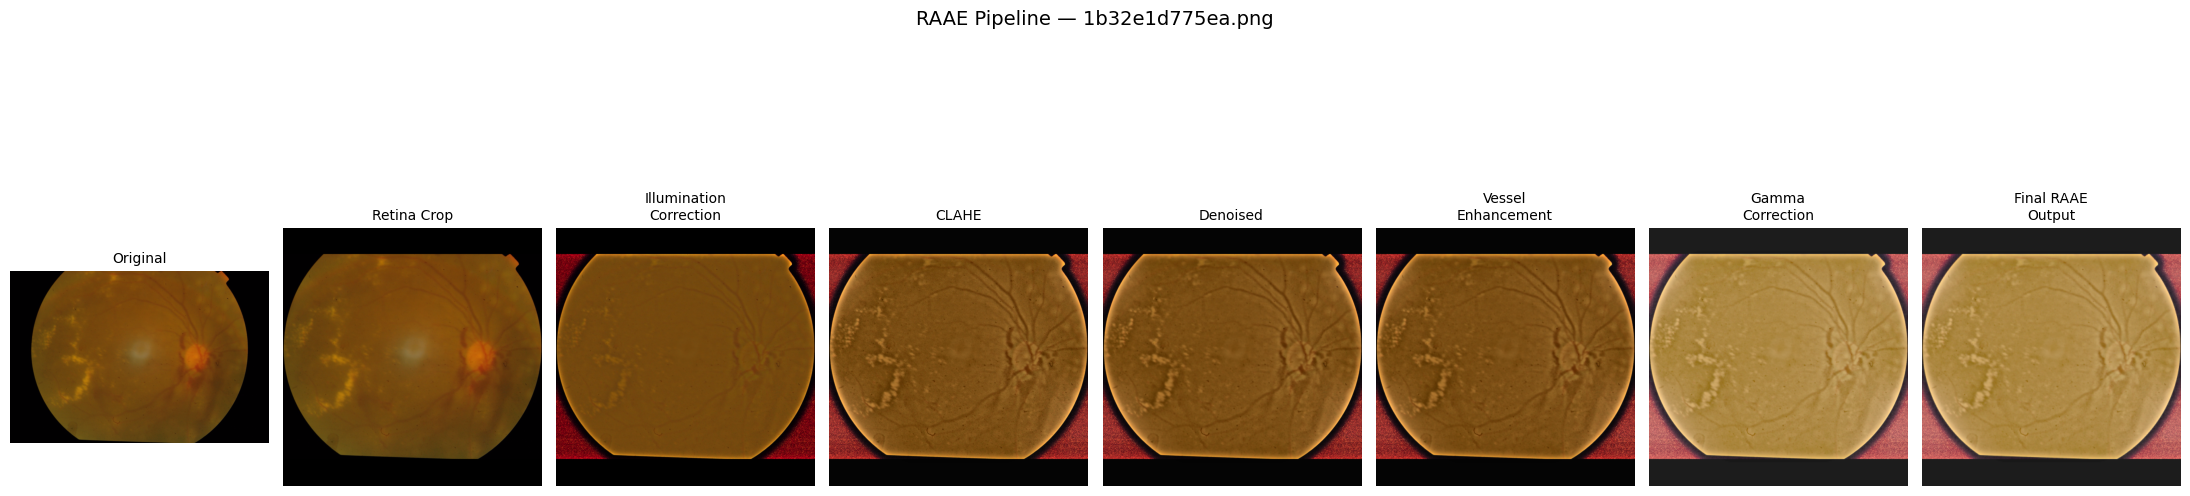

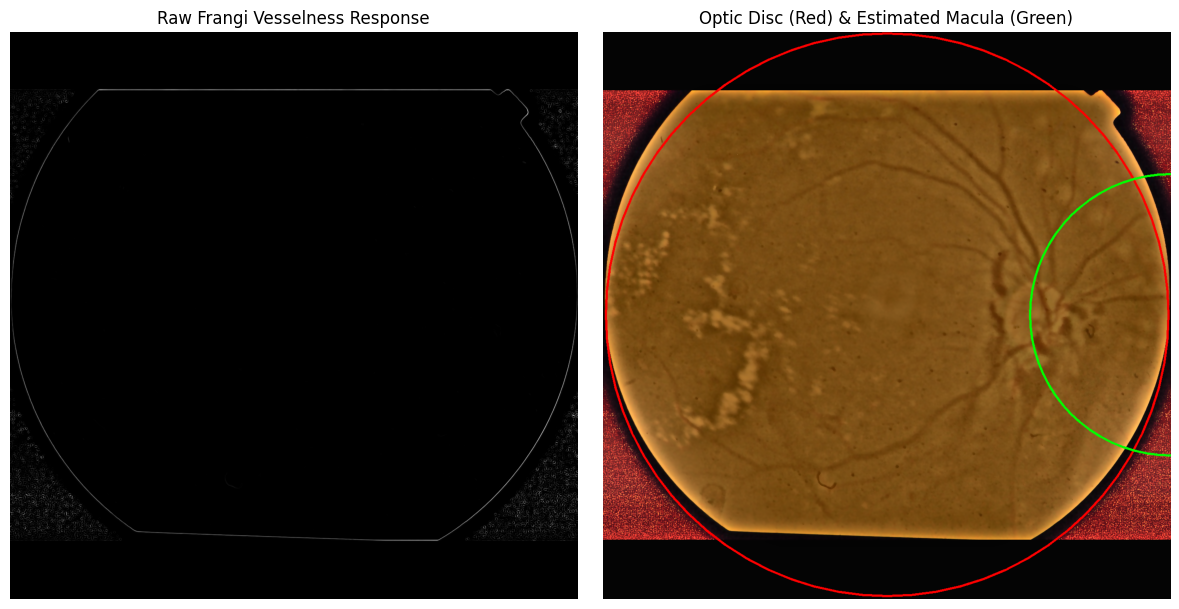

In [47]:
# =============================================================================
# Visualize RAAE Pipeline
# =============================================================================

def visualize_pipeline(image_path, figsize=(22, 6)):
    """
    Visualize every stage of the Retina Anatomy-Aware Enhancement (RAAE) pipeline.
    """

    # -------------------------------------------------------------------------
    # Convert Path object to string (required by OpenCV)
    # -------------------------------------------------------------------------
    image_path = str(image_path)

    print(f"\nProcessing: {image_path}")

    # -------------------------------------------------------------------------
    # Read image
    # -------------------------------------------------------------------------
    image_bgr = cv2.imread(image_path)

    if image_bgr is None:
        print(f"[ERROR] Could not read image:\n{image_path}")
        return

    print(f"Image shape: {image_bgr.shape}")

    # -------------------------------------------------------------------------
    # Run RAAE pipeline
    # -------------------------------------------------------------------------
    try:
        result = raae_pipeline(image_bgr, verbose=True)
    except Exception as e:
        print(f"[ERROR] RAAE pipeline failed:\n{e}")
        raise

    # -------------------------------------------------------------------------
    # Display all enhancement stages
    # -------------------------------------------------------------------------
    stage_order = [
        ("Original", cv2.cvtColor(result["original"], cv2.COLOR_BGR2RGB)),
        ("Retina Crop", cv2.cvtColor(result["retina_crop"], cv2.COLOR_BGR2RGB)),
        ("Illumination\nCorrection", cv2.cvtColor(result["illumination_corrected"], cv2.COLOR_BGR2RGB)),
        ("CLAHE", cv2.cvtColor(result["clahe"], cv2.COLOR_BGR2RGB)),
        ("Denoised", cv2.cvtColor(result["denoised"], cv2.COLOR_BGR2RGB)),
        ("Vessel\nEnhancement", cv2.cvtColor(result["vessel_enhanced"], cv2.COLOR_BGR2RGB)),
        ("Gamma\nCorrection", cv2.cvtColor(result["gamma_corrected"], cv2.COLOR_BGR2RGB)),
        ("Final RAAE\nOutput", result["final_rgb"]),
    ]

    fig, axes = plt.subplots(1, len(stage_order), figsize=figsize)

    for ax, (title, img) in zip(axes, stage_order):
        ax.imshow(img)
        ax.set_title(title, fontsize=10)
        ax.axis("off")

    plt.suptitle(
        f"RAAE Pipeline — {os.path.basename(image_path)}",
        fontsize=14,
        y=1.05,
    )

    plt.tight_layout()
    plt.show()

    # -------------------------------------------------------------------------
    # Vessel Map + Landmark Visualization
    # -------------------------------------------------------------------------
    fig2, axes2 = plt.subplots(1, 2, figsize=(12, 6))

    axes2[0].imshow(result["vessel_map"], cmap="gray")
    axes2[0].set_title("Raw Frangi Vesselness Response")
    axes2[0].axis("off")

    landmark_display = cv2.cvtColor(
        result["denoised"],
        cv2.COLOR_BGR2RGB,
    ).copy()

    if result["landmarks"] is not None:

        dcx, dcy, dr = result["landmarks"]["optic_disc"]
        mx, my = result["landmarks"]["macula_estimate"]

        cv2.circle(landmark_display, (dcx, dcy), dr, (255, 0, 0), 3)
        cv2.circle(
            landmark_display,
            (mx, my),
            max(dr // 2, 15),
            (0, 255, 0),
            3,
        )

        axes2[1].set_title(
            "Optic Disc (Red) & Estimated Macula (Green)"
        )

    else:
        axes2[1].set_title("Optic Disc Not Confidently Detected")

    axes2[1].imshow(landmark_display)
    axes2[1].axis("off")

    plt.tight_layout()
    plt.show()


# =============================================================================
# Visualize Sample Images
# =============================================================================

SAMPLE_VISUALIZATION_COUNT = 3

print(f"Total images found: {len(image_paths)}")

if len(image_paths) == 0:
    print("[ERROR] No images found.")
else:
    print("Displaying sample images...\n")

    sample_paths = image_paths[:SAMPLE_VISUALIZATION_COUNT]

    for idx, image_path in enumerate(sample_paths, start=1):
        print("=" * 80)
        print(f"Sample {idx}/{len(sample_paths)}")
        visualize_pipeline(image_path)